# Módulo 4 — Valor en Riesgo (VaR) por Monte Carlo

**Proyecto:** Métodos de Monte Carlo en Finanzas Cuantitativas
**Autor:** Jorge Rodríguez Lázaro
**Última actualización:** 2026-09-26

---

## Objetivo del módulo

Los módulos anteriores preguntaban *cuánto vale* un activo o un contrato. Este pregunta lo contrario y complementario: **¿cuánto podría perder?** Es la primera **medida de riesgo** del proyecto, y la más extendida en la industria: el **Valor en Riesgo (VaR)**.

Construimos el VaR por tres vías —paramétrica, histórica y Monte Carlo—, las comparamos sobre datos reales, validamos el modelo por *backtesting* y cerramos con un análisis honesto de las limitaciones del VaR (que son serias y bien conocidas), introduciendo su primo mejor comportado, el **Expected Shortfall (CVaR)**.

Reutilizamos el motor de simulación del paquete `mcquant` construido a lo largo del proyecto.

## Estructura

| Sección | Tema | Idea clave |
|---------|------|------------|
| 1 | Qué es el VaR | Definición, horizonte y confianza; medida física (no neutral al riesgo). |
| 2 | VaR y CVaR por Monte Carlo | Simular la distribución de pérdidas y leer su cola. |
| 3 | Tres métodos comparados | Paramétrico vs. histórico vs. Monte Carlo sobre SPY. |
| 4 | Validación y límites | Backtesting, no subaditividad, y por qué el CVaR es mejor medida. |

## Referencias

- Jorion, P. (2006). *Value at Risk: The New Benchmark for Managing Financial Risk*, 3.ª ed.
- Hull, J. C. (2018). *Options, Futures and Other Derivatives*, cap. 22.
- McNeil, Frey & Embrechts (2015). *Quantitative Risk Management*, caps. 2 y 8.
- Artzner, Delbaen, Eber & Heath (1999). *Coherent Measures of Risk*. Mathematical Finance.

> **Nota sobre el código.** Este módulo usa el paquete `mcquant` (`simular_gbm`, `simular_precio_final`, `estimar_parametros`) construido en los módulos anteriores. Se importa con `from mcquant import ...`.

---

# Sección 1 — Qué es el Valor en Riesgo

## 1.1 De valorar a medir el riesgo

Un gestor de cartera no solo quiere saber cuánto vale su cartera hoy; necesita cuantificar **cuánto podría perder en un plazo dado**. El VaR responde esa pregunta con un único número, y por eso lo adoptaron reguladores (Basilea) y mesas de trading en los años 90.

**Definición.** El VaR a un nivel de confianza $c$ (p. ej. 99 %) y horizonte $h$ (p. ej. 1 día) es la **pérdida que solo se supera con probabilidad $1-c$**:

$$
\mathbb{P}(\text{Pérdida} > \text{VaR}_c) = 1 - c
$$

En palabras: *"con un 99 % de confianza, en un día no perderé más de X euros"*. Equivalentemente, X es el cuantil $c$ de la distribución de pérdidas. Un VaR a 1 día al 99 % de 20.000 € significa que un día de cada 100, en promedio, la pérdida excederá esos 20.000 €.

## 1.2 Un matiz crucial: aquí el drift SÍ importa

En el Módulo 3, para *valorar* opciones, simulábamos bajo la medida neutral al riesgo (drift $= r$). **Para medir riesgo es al revés: usamos la medida física (el mundo real), con el drift real $\mu$ y no $r$.**

La razón es que el VaR trata sobre **pérdidas y ganancias efectivas** de una posición: nos importa la distribución *real* de resultados que va a experimentar la cartera, no un precio de no-arbitraje. Es una distinción conceptual importante que conecta con el Módulo 2: la valoración de derivados esquiva el drift inestimable, pero la gestión de riesgo no puede — necesita $\mu$, con toda su incertidumbre. Volveremos sobre esta fragilidad en la Sección 4.

## 1.3 Tres formas de obtener la distribución de pérdidas

Todo se reduce a conocer la distribución de la pérdida a horizonte $h$. Hay tres enfoques clásicos, y los implementamos los tres:

1. **Paramétrico** (varianza-covarianza): supone que las rentabilidades son normales y usa la fórmula cerrada del cuantil. Rápido, pero hereda el pecado del Módulo 2 §4 — ignora las colas gruesas.
2. **Histórico**: usa directamente la distribución empírica de las rentabilidades pasadas. No supone normalidad, pero está limitado a lo que ya ocurrió.
3. **Monte Carlo**: simula bajo un modelo (aquí, el GBM). Flexible y extensible a carteras y derivados complejos — nuestro protagonista.

---

# Sección 2 — VaR y CVaR por Monte Carlo

## 2.1 El planteamiento

Consideramos una posición de valor $V_0$ invertida en un activo que sigue un GBM con parámetros $\mu, \sigma$ estimados de datos reales (Módulo 2). El algoritmo es directo:

1. Simular $N$ precios del activo a horizonte $h$ bajo la medida física: $S_h^{(i)}$.
2. Convertir a pérdidas y ganancias de la posición: $\text{P\&L}^{(i)} = V_0\left(S_h^{(i)}/S_0 - 1\right)$, y la pérdida es $L^{(i)} = -\text{P\&L}^{(i)}$.
3. Leer el cuantil $c$ de las pérdidas simuladas: ese es el $\text{VaR}_c$.

Además del VaR calculamos el **Expected Shortfall** (o CVaR): la **pérdida media *condicionada* a que se supere el VaR**,

$$
\text{ES}_c = \text{media de la fracción } (1-c) \text{ de peores pérdidas} \;\;\big(=\mathbb{E}[L \mid L > \text{VaR}_c] \text{ si } L \text{ es continua}\big)
$$

El VaR dice *"cuánto es el umbral que casi nunca supero"*; el ES dice *"y si lo supero, cuánto pierdo en promedio"* — responde a la pregunta que el VaR deja abierta, la severidad de los desastres. (La definición como media de la peor fracción, y no como la esperanza condicional ingenua, es la que hace al ES *coherente*; volveremos a ello en la Sección 4.2.)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import norm

from mcquant import estimar_parametros, simular_precio_final

rng = np.random.default_rng(seed=42)

# Cargamos el histórico de SPY cacheado (mismo dato que el Módulo 2)
for carpeta in ("../data", "data"):
    csv = Path(carpeta) / "spy_prices.csv"
    if csv.exists():
        precios = pd.read_csv(csv, index_col="Date", parse_dates=True).iloc[:, 0]
        break

log_ret = np.log(precios / precios.shift(1)).dropna()
mu, sigma = estimar_parametros(precios)
print(f"SPY 2015–2023 | μ̂ = {mu:.4f} ({mu*100:.1f}%),  σ̂ = {sigma:.4f} ({sigma*100:.1f}%)")

SPY 2015–2023 | μ̂ = 0.1279 (12.8%),  σ̂ = 0.1816 (18.2%)


In [2]:
def expected_shortfall(perdidas, conf):
    """ES / CVaR coherente: media de la fracción (1 - conf) de peores pérdidas.

    Para distribuciones continuas coincide con E[L | L > VaR]; para distribuciones
    con saltos (átomos) esta es la versión correcta y coherente (subaditiva).
    """
    k = max(1, int(np.ceil(len(perdidas) * (1 - conf))))
    return np.sort(perdidas)[-k:].mean()


def var_cvar_montecarlo(V0, S0, mu, sigma, h, N, rng, conf=0.99):
    """VaR y Expected Shortfall (CVaR) por Monte Carlo a horizonte h (en años).

    Simula bajo la medida física (drift real mu) y devuelve (VaR, CVaR) en euros,
    ambos como pérdidas positivas.
    """
    S_h = simular_precio_final(S0, mu, sigma, h, N, rng)
    pnl = V0 * (S_h / S0 - 1.0)
    perdidas = -pnl
    var = np.quantile(perdidas, conf)
    cvar = expected_shortfall(perdidas, conf)
    return var, cvar, perdidas

## 2.2 VaR de una posición de 1 000 000 € en SPY

Tomamos una posición de un millón de euros, horizonte de 1 día ($h = 1/252$), y calculamos el VaR y el CVaR al 95 % y al 99 %. El histograma muestra la distribución de pérdidas y ganancias simulada, con las líneas de VaR y CVaR marcadas en la cola izquierda.

 Confianza        VaR (€)    CVaR/ES (€)
----------------------------------------
       95%         18,244         22,909
       99%         25,874         29,655


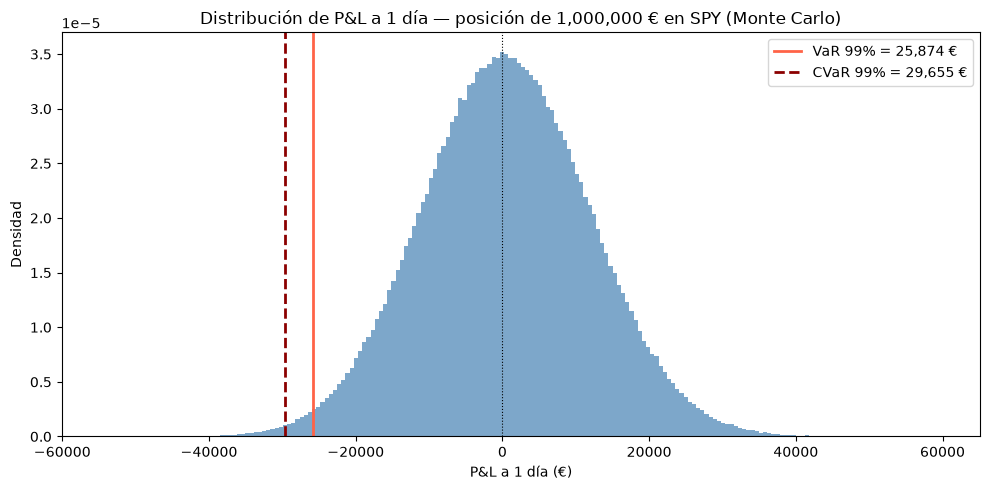

In [3]:
V0 = 1_000_000.0
S0 = precios.iloc[-1]
h  = 1 / 252

_, _, perdidas = var_cvar_montecarlo(V0, S0, mu, sigma, h, 1_000_000, rng, conf=0.99)

print(f"{'Confianza':>10} {'VaR (€)':>14} {'CVaR/ES (€)':>14}")
print("-" * 40)
for c in (0.95, 0.99):
    var = np.quantile(perdidas, c)
    cvar = expected_shortfall(perdidas, c)
    print(f"{c:>10.0%} {var:>14,.0f} {cvar:>14,.0f}")

pnl = -perdidas
var99 = np.quantile(perdidas, 0.99)
cvar99 = expected_shortfall(perdidas, 0.99)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(pnl, bins=200, color='steelblue', alpha=0.7, density=True)
ax.axvline(-var99, color='tomato', linewidth=2, label=f'VaR 99% = {var99:,.0f} €')
ax.axvline(-cvar99, color='darkred', linewidth=2, linestyle='--', label=f'CVaR 99% = {cvar99:,.0f} €')
ax.axvline(0, color='black', linewidth=0.8, linestyle=':')
ax.set_xlabel('P&L a 1 día (€)'); ax.set_ylabel('Densidad')
ax.set_title(f'Distribución de P&L a 1 día — posición de {V0:,.0f} € en SPY (Monte Carlo)')
ax.legend()
plt.tight_layout(); plt.show()

Obsérvese que el CVaR (la pérdida media en el 1 % peor de los casos) es siempre mayor que el VaR: el VaR marca la *entrada* a la cola, el CVaR promedia *dentro* de ella. Escalar el horizonte también es inmediato en Monte Carlo — basta cambiar $h$. La regla clásica de la raíz del tiempo (VaR a $h$ días $\approx \sqrt{h}\cdot$ VaR a 1 día) sale sola porque la volatilidad escala con $\sqrt{h}$:

In [4]:
print(f"{'Horizonte':>12} {'VaR 99% (€)':>14} {'√h · VaR_1d':>14}")
print("-" * 44)
var_1d, _, _ = var_cvar_montecarlo(V0, S0, mu, sigma, 1/252, 1_000_000, rng, 0.99)
for dias in (1, 5, 10, 20):
    var_h, _, _ = var_cvar_montecarlo(V0, S0, mu, sigma, dias/252, 1_000_000, rng, 0.99)
    print(f"{dias:>10} d {var_h:>14,.0f} {np.sqrt(dias)*var_1d:>14,.0f}")

   Horizonte    VaR 99% (€)    √h · VaR_1d
--------------------------------------------
         1 d         25,816         25,777
         5 d         55,801         57,639


        10 d         76,378         81,514
        20 d        104,440        115,278


---

# Sección 3 — Tres métodos comparados

El VaR es tan bueno como el supuesto sobre la distribución de pérdidas. Comparamos los tres enfoques sobre la misma posición y horizonte (1 día), para ver cuánto discrepan.

**Paramétrico (normal).** Si las rentabilidades son normales con media $\mu h$ y desviación $\sigma\sqrt{h}$, el VaR tiene fórmula cerrada:

$$
\text{VaR}_c = V_0\left(z_c\, \sigma\sqrt{h} - \mu h\right), \qquad z_c = \Phi^{-1}(c)
$$

**Histórico.** Se aplican las rentabilidades diarias *reales* observadas a la posición y se toma el cuantil empírico de las pérdidas. No supone ninguna forma de distribución.

**Monte Carlo.** El de la Sección 2.

In [5]:
h = 1 / 252

# 1) Paramétrico (normal)
def var_parametrico(V0, mu, sigma, h, conf):
    z = norm.ppf(conf)
    return V0 * (z * sigma * np.sqrt(h) - mu * h)

# 2) Histórico: P&L real de aplicar cada rentabilidad diaria observada
def var_historico(V0, log_ret, conf):
    pnl_hist = V0 * (np.exp(log_ret.values) - 1.0)
    return np.quantile(-pnl_hist, conf)

# 3) Monte Carlo (Sección 2)
print(f"{'Método':<14} {'VaR 95% (€)':>14} {'VaR 99% (€)':>14}")
print("-" * 46)
for nombre, f95, f99 in [
    ("Paramétrico", var_parametrico(V0, mu, sigma, h, 0.95), var_parametrico(V0, mu, sigma, h, 0.99)),
    ("Histórico",   var_historico(V0, log_ret, 0.95),        var_historico(V0, log_ret, 0.99)),
    ("Monte Carlo", var_cvar_montecarlo(V0, S0, mu, sigma, h, 1_000_000, rng, 0.95)[0],
                    var_cvar_montecarlo(V0, S0, mu, sigma, h, 1_000_000, rng, 0.99)[0]),
]:
    print(f"{nombre:<14} {f95:>14,.0f} {f99:>14,.0f}")

Método            VaR 95% (€)    VaR 99% (€)
----------------------------------------------
Paramétrico            18,308         26,104
Histórico              17,336         33,122
Monte Carlo            18,189         25,818


## 3.1 Dónde discrepan: las colas gruesas atacan de nuevo

Al 95 %, los tres métodos dan cifras parecidas — cerca del centro de la distribución todo es aproximadamente normal. Pero **al 99 %, donde vive el riesgo de verdad, el histórico supera al paramétrico**: es la manifestación directa de las colas gruesas que documentamos en el Módulo 2 §4. El método paramétrico normal **subestima** el riesgo extremo porque la campana de Gauss no cree en los desplomes que el mercado sí produce.

El Monte Carlo, al estar también basado en el GBM (rentabilidades normales), se parece al paramétrico — comparte su optimismo sobre las colas. Su ventaja no es la precisión en la cola de *este* caso simple, sino la flexibilidad: puede incorporar carteras, correlaciones y payoffs no lineales donde no hay fórmula. Lo vemos comparando la cola izquierda empírica con la normal ajustada:

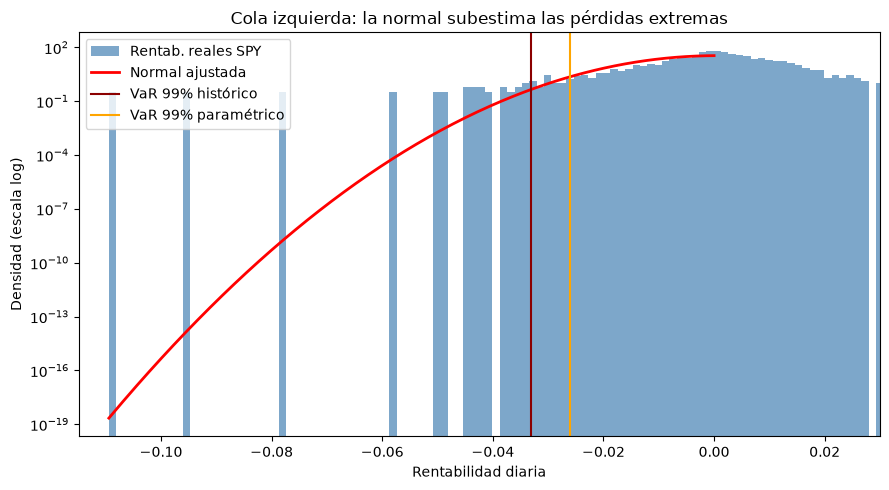

Peor día real: -10.9%. VaR 99% paramétrico (como rentab.): -2.61%


In [6]:
pnl_hist = np.exp(log_ret.values) - 1.0   # rentab. simple diaria real
x = np.linspace(pnl_hist.min(), 0.0, 300)

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(pnl_hist, bins=150, density=True, color='steelblue', alpha=0.7, label='Rentab. reales SPY')
ax.plot(x, norm.pdf(x, pnl_hist.mean(), pnl_hist.std()), 'r-', linewidth=2, label='Normal ajustada')
ax.axvline(-var_historico(1, log_ret, 0.99), color='darkred', linewidth=1.5, label='VaR 99% histórico')
ax.axvline(-var_parametrico(1, mu, sigma, h, 0.99), color='orange', linewidth=1.5, label='VaR 99% paramétrico')
ax.set_xlim(pnl_hist.min() * 1.05, 0.03)
ax.set_yscale('log')
ax.set_xlabel('Rentabilidad diaria'); ax.set_ylabel('Densidad (escala log)')
ax.set_title('Cola izquierda: la normal subestima las pérdidas extremas')
ax.legend()
plt.tight_layout(); plt.show()

peor = pnl_hist.min()
print(f"Peor día real: {peor*100:.1f}%. VaR 99% paramétrico (como rentab.): {-var_parametrico(1, mu, sigma, h, 0.99)*100:.2f}%")

---

# Sección 4 — Validación y límites

## 4.1 Backtesting: ¿cuántas veces falló el VaR?

Un VaR al 99 % debería ser superado, por definición, en **el 1 % de los días**. El *backtesting* comprueba esto contando las **excepciones** (días en que la pérdida real superó el VaR estimado) sobre el histórico. Si hay demasiadas, el modelo subestima el riesgo; si demasiado pocas, lo sobreestima (y ata capital de más).

In [7]:
for conf in (0.95, 0.99):
    var_umbral = var_historico(1.0, log_ret, conf)   # VaR como fracción, base 1
    perdidas_reales = -(np.exp(log_ret.values) - 1.0)
    excepciones = np.sum(perdidas_reales > var_umbral)
    n = len(perdidas_reales)
    esperadas = (1 - conf) * n
    print(f"VaR {conf:.0%}: {excepciones} excepciones de {n} días "
          f"({excepciones/n:.2%})  |  esperadas: {esperadas:.0f} ({1-conf:.0%})")

VaR 95%: 114 excepciones de 2263 días (5.04%)  |  esperadas: 113 (5%)
VaR 99%: 23 excepciones de 2263 días (1.02%)  |  esperadas: 23 (1%)


El VaR histórico está, por construcción, bien calibrado en la muestra (las excepciones coinciden con lo esperado). El verdadero *backtest* exigente sería fuera de muestra o con el método paramétrico, que produciría **más** excepciones de las debidas al 99 % — otra vez, el efecto de las colas.

## 4.2 El talón de Aquiles del VaR: no es subaditivo

El VaR tiene un defecto teórico grave, señalado por Artzner et al. (1999): **no siempre premia la diversificación**. Una medida de riesgo *coherente* debería cumplir la **subaditividad** — el riesgo de una cartera combinada nunca debería superar la suma de los riesgos por separado ($\rho(A+B) \le \rho(A) + \rho(B)$) —. El VaR puede violarlo.

Lo mostramos con el ejemplo clásico de dos bonos que solo pueden impagar (default). Cada uno pierde 100 con probabilidad del 4 % (independientes). Al 95 %:

In [8]:
rng2 = np.random.default_rng(1)
N = 2_000_000
p_default = 0.04

perdida_A = np.where(rng2.random(N) < p_default, 100.0, 0.0)
perdida_B = np.where(rng2.random(N) < p_default, 100.0, 0.0)
cartera   = perdida_A + perdida_B

conf = 0.95
var_A = np.quantile(perdida_A, conf)
var_B = np.quantile(perdida_B, conf)
var_AB = np.quantile(cartera, conf)

print(f"VaR 95% del bono A:            {var_A:6.1f}")
print(f"VaR 95% del bono B:            {var_B:6.1f}")
print(f"Suma de VaR individuales:      {var_A + var_B:6.1f}")
print(f"VaR 95% de la cartera A+B:     {var_AB:6.1f}")
print()
if var_AB > var_A + var_B:
    print("¡VIOLACIÓN de subaditividad!  VaR(A+B) > VaR(A) + VaR(B):")
    print("diversificar AUMENTA el VaR — un absurdo que el VaR permite.")

# El Expected Shortfall sí es coherente (subaditivo):
es_sum = expected_shortfall(perdida_A, conf) + expected_shortfall(perdida_B, conf)
es_AB = expected_shortfall(cartera, conf)
print(f"\nExpected Shortfall 95%:  ES(A)+ES(B) = {es_sum:.1f}, "
      f"ES(A+B) = {es_AB:.1f}  →  ES(A+B) ≤ ES(A)+ES(B), subaditivo (coherente)")

VaR 95% del bono A:               0.0
VaR 95% del bono B:               0.0
Suma de VaR individuales:         0.0
VaR 95% de la cartera A+B:      100.0

¡VIOLACIÓN de subaditividad!  VaR(A+B) > VaR(A) + VaR(B):
diversificar AUMENTA el VaR — un absurdo que el VaR permite.

Expected Shortfall 95%:  ES(A)+ES(B) = 160.5, ES(A+B) = 103.3  →  ES(A+B) ≤ ES(A)+ES(B), subaditivo (coherente)


Cada bono, aislado, tiene VaR 95 % **cero** (la probabilidad de impago, 4 %, es menor que el 5 %, así que el cuantil 95 % de la pérdida es 0). Pero la cartera tiene una probabilidad de al menos un impago de $1 - 0.96^2 \approx 7.8\% > 5\%$, así que su VaR 95 % es 100. Resultado: **el VaR dice que juntar los dos bonos es más arriesgado que tenerlos por separado**, penalizando la diversificación. Es un sinsentido económico, y es la razón por la que la regulación (Basilea III/FRTB) migró del VaR al **Expected Shortfall**, que sí es coherente.

## 4.3 Cierre del módulo

**Qué hemos construido.** El VaR y el Expected Shortfall por tres métodos (paramétrico, histórico, Monte Carlo), su comparación sobre datos reales, el *backtesting* de excepciones y la demostración de la no subaditividad del VaR.

**Análisis honesto.**

1. **La distribución lo es todo.** El VaR paramétrico normal subestima el riesgo de cola precisamente por las colas gruesas del Módulo 2. El histórico las captura pero no ve más allá del pasado. Monte Carlo es flexible pero solo tan bueno como su modelo — con GBM, comparte el optimismo de la normal.
2. **El drift vuelve a ser un problema.** A diferencia de la valoración de opciones, el riesgo depende del drift real $\mu$, que sabemos (Módulo 2 §3.3) que es casi inestimable. A horizontes cortos su efecto es pequeño (domina $\sigma\sqrt{h}$), pero a horizontes largos la incertidumbre sobre $\mu$ contamina el VaR.
3. **El VaR como número único engaña.** No dice nada sobre la severidad más allá del umbral y no es coherente. El **Expected Shortfall** corrige ambos defectos y es hoy el estándar regulatorio.

**Cierre del proyecto (Peldaños 0–4).** Con este módulo cerramos el núcleo del proyecto: partiendo de Monte Carlo puro (π, paseo aleatorio, TCL), construimos un modelo de precios (GBM), lo calibramos con datos reales, valoramos opciones contrastando contra Black–Scholes, y medimos riesgo con VaR y ES. El hilo conductor ha sido siempre el mismo —**estimar una esperanza simulando el azar y promediando, con rigor estadístico y honestidad sobre las limitaciones**—, y a estas alturas está respaldado por un paquete instalable, tests y CI. El Peldaño 5 (opcional) queda para ampliaciones: reducción de varianza, Griegas por Monte Carlo y análisis de convergencia.

## Referencias

- Artzner, P., Delbaen, F., Eber, J.-M. & Heath, D. (1999). *Coherent Measures of Risk*. Mathematical Finance, 9(3).
- Jorion, P. (2006). *Value at Risk*, 3.ª ed.
- Hull, J. C. (2018). *Options, Futures and Other Derivatives*, cap. 22.
- McNeil, Frey & Embrechts (2015). *Quantitative Risk Management*, caps. 2 y 8.